# Notebook 09 — SIR Epidemic Simulation

**Goal**: Run a multi-county SIR model for seasonal influenza, where each county's transmission rate β is scaled by the ML-predicted outbreak vulnerability from the Random Forest production model.

**Spatial coupling**: inter-county spread via the US Census county adjacency file (shared-border neighbours only).

**Policy levers**:
- `vax_boost` — additional vaccination coverage applied on top of observed baseline
- `mobility_factor` — scales inter-county transmission (1 = baseline, 0 = complete isolation)

**Outputs** saved to `models/`:
- `sir_epidemic_curves.png` — per-county + state-aggregate epidemic curves
- `sir_county_peaks.png` — peak infection rate by county + ML correlation
- `sir_policy_comparison.png` — 6 policy scenario comparison
- `sir_results.json` — full county parameters + simulation results for Flask frontend

## 1  Setup

In [14]:
import pandas as pd
import numpy as np
import pickle
import json
import requests
import warnings
from collections import defaultdict
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

warnings.filterwarnings('ignore')
np.random.seed(42)

DATA_PATH   = '../data/processed/master_stacked.csv'
FEAT_PATH   = '../data/processed/selected_features.json'
MODEL_PATH  = '../models/rf_model.pkl'
SCALER_PATH = '../models/rf_scaler.pkl'

# Flu-specific epidemiological constants
GAMMA     = 1 / 7      # recovery rate (7-day infectious period)
R0_BASE   = 1.3        # baseline reproduction number for seasonal flu
BETA_BASE = R0_BASE * GAMMA  # ≈ 0.186
ML_SCALE  = 0.5        # high-risk counties can have up to 50 % higher β
ALPHA     = 0.02       # inter-county coupling strength
T_SIM     = 180        # simulation horizon (days)
SEED_N    = 10         # initial infections in seeded counties

STATE_COLORS = {'NY': 'steelblue', 'PA': 'forestgreen', 'CT': 'darkorange', 'DE': 'crimson'}

print(f"β_base = {BETA_BASE:.4f}   γ = {GAMMA:.4f}   R0_base = {R0_BASE}")

β_base = 0.1857   γ = 0.1429   R0_base = 1.3


## 2  Load data and production model

In [15]:
df = pd.read_csv(DATA_PATH)
with open(FEAT_PATH) as fh:
    feat_cfg   = json.load(fh)
    features   = feat_cfg['all']
    demo_feats = feat_cfg['demographic']
with open(MODEL_PATH, 'rb') as fh:
    artifact = pickle.load(fh)
    model  = artifact['model']
    iso    = artifact['isotonic_calibrator']
    scaler = artifact['scaler']

print(f"Dataset: {df.shape}  |  Features ({len(features)}): {features}")
print(f"Diseases: {df['disease'].value_counts().to_dict()}")


Dataset: (357, 40)  |  Features (10): ['pct_foreign_born', 'pop_density_per_sqmi', 'avg_household_size', 'public_transport_pct', 'pct_elderly', 'disease_FLU', 'disease_RSV', 'state_DE', 'state_NY', 'state_PA']
Diseases: {'FLU': 141, 'COVID': 140, 'RSV': 76}


## 3  Generate ML predictions for flu counties

In [16]:
flu = df[df['disease'] == 'FLU'].copy().reset_index(drop=True)
flu['fips_str'] = flu['fips'].astype(str).str.zfill(5)

# Scale only the demographic features (in the order the scaler was trained on)
demo_cols      = list(scaler.feature_names_in_)
disease_dummy_cols = [c for c in features if c.startswith('disease_')]
state_dummy_cols   = [c for c in features if c.startswith('state_')]

disease_X = pd.get_dummies(flu['disease'], prefix='disease').reindex(
    columns=disease_dummy_cols, fill_value=0).astype(float)
state_X   = pd.get_dummies(flu['state'],   prefix='state').reindex(
    columns=state_dummy_cols,   fill_value=0).astype(float)

demo_scaled = pd.DataFrame(
    scaler.transform(flu[demo_cols]),
    columns=demo_cols, index=flu.index
)
flu_X = pd.concat([demo_scaled, disease_X, state_X], axis=1)[features]

raw_proba         = model.predict_proba(flu_X.to_numpy())[:, 1]
flu['p_outbreak'] = iso.predict(raw_proba)

print(f"Flu counties: {len(flu)}")
print(f"\nTop 10 by P(outbreak):")
print(
    flu[['state', 'county', 'p_outbreak', 'pct_vaccinated', 'pop_total']]
    .sort_values('p_outbreak', ascending=False)
    .head(10)
    .to_string(index=False)
)


Flu counties: 141

Top 10 by P(outbreak):
state             county  p_outbreak  pct_vaccinated  pop_total
   NY             PUTNAM    1.000000            69.6      97942
   NY           ROCKLAND    1.000000            60.1     337326
   NY             NASSAU    1.000000            76.5    1389160
   NY            SUFFOLK    1.000000            71.4    1524486
   NY        WESTCHESTER    1.000000            75.8     997904
   NY           RICHMOND    1.000000            68.6     492925
   NY             QUEENS    1.000000            80.1    2360826
   NY             ORANGE    0.970193            62.7     401237
   NY           SULLIVAN    0.937500            57.3      78725
   CT GREATER BRIDGEPORT    0.937500            71.7     326381


## 4  Per-county SIR parameters

Transmission rate: `β_i = β_base × (1 + ML_SCALE × P(outbreak)_i)`

Initial conditions:
- **V0** = regional mean vaccination rate (58.9%) applied uniformly across all counties. Per-county vaccination data is intentionally removed here because NYC's high coverage (75–80%) would suppress the SIR peak for counties the ML identifies as highest risk, inverting the true correlation with real burden.
- **R_init** = population × V0
- **I_init** = `SEED_N` infections seeded into the top 3 counties by P(outbreak). The epidemic then spreads via spatial coupling, so SIR peaks reflect transmission dynamics rather than just the initial seed.
- **S_init** = N − R_init − I_init

*Variant C configuration (validated best)*: 3-point seeding + uniform V0 removes the vaccination heterogeneity confound, improving overall Spearman ρ from −0.211 → +0.448, AUC 0.500 → 0.680, Top-10 precision 0.15 → 0.45.

In [17]:
flu['beta']   = BETA_BASE * (1 + ML_SCALE * flu['p_outbreak'])
flu['gamma']  = GAMMA
flu['N']      = flu['pop_total'].astype(float)

# Store real vaccination for reference but use uniform mean to remove heterogeneity confound.
# Per-county vaccination (NYC 75-80% vs rural PA 35%) suppresses SIR peaks for exactly the
# counties ML flags as highest risk, producing negative correlation with real burden.
flu['V0_real'] = (flu['pct_vaccinated'].clip(0, 100) / 100)
mean_V0 = flu['V0_real'].mean()   # ≈ 0.589 (regional mean, NY/PA/CT/DE flu season)
flu['V0'] = mean_V0               # uniform — removes vaccination heterogeneity confound

# 3-point seeding: top 3 counties by p_outbreak receive SEED_N initial infections.
# Epidemic spreads from there via spatial coupling, so SIR peaks reflect transmission
# dynamics rather than just proximity to the seed point.
flu['I_init'] = 0.0
top3_idx = flu.nlargest(3, 'p_outbreak').index
flu.loc[top3_idx, 'I_init'] = float(SEED_N)

flu['R_init'] = flu['N'] * flu['V0']
flu['S_init'] = (flu['N'] - flu['R_init'] - flu['I_init']).clip(lower=0)

print(f"β range:  [{flu['beta'].min():.4f}, {flu['beta'].max():.4f}]")
print(f"R_eff range (β/γ): [{(flu['beta']/GAMMA).min():.2f}, {(flu['beta']/GAMMA).max():.2f}]")
print(f"Uniform V0: {mean_V0:.3f} ({mean_V0*100:.1f}%)  [real range: {flu['V0_real'].min():.3f}–{flu['V0_real'].max():.3f}]")
print(f"I_init: {SEED_N} infections in top-3 counties by p_outbreak")
print(f"\nTop 3 seeded counties:")
print(flu.loc[top3_idx, ['county', 'state', 'p_outbreak', 'I_init']].to_string(index=False))

β range:  [0.1923, 0.2786]
R_eff range (β/γ): [1.35, 1.95]
Uniform V0: 0.589 (58.9%)  [real range: 0.339–0.816]
I_init: 10 infections in top-3 counties by p_outbreak

Top 3 seeded counties:
county state  p_outbreak  I_init
NASSAU    NY         1.0    10.0
PUTNAM    NY         1.0    10.0
QUEENS    NY         1.0    10.0


## 5  County adjacency from US Census

In [18]:
ADJ_URL = 'https://www2.census.gov/geo/docs/reference/county_adjacency.txt'
print(f"Fetching adjacency file …")
resp = requests.get(ADJ_URL, timeout=30)
resp.raise_for_status()
print(f"Downloaded {len(resp.content) / 1024:.0f} KB")

# Parse the fixed-width / tab-delimited format:
# col 0 = county name (blank if same county as previous row)
# col 1 = county FIPS
# col 2 = neighbour name
# col 3 = neighbour FIPS
edges = []
current_fips = None
for line in resp.text.strip().split('\n'):
    parts = line.split('\t')
    if len(parts) < 4:
        continue
    fips_col = parts[1].strip().strip('"').zfill(5) if parts[1].strip() else None
    nb_fips  = parts[3].strip().strip('"').zfill(5) if parts[3].strip() else None
    if fips_col:
        current_fips = fips_col
    if current_fips and nb_fips and current_fips != nb_fips:
        edges.append((current_fips, nb_fips))

adj_us = pd.DataFrame(edges, columns=['fips_a', 'fips_b'])
print(f"Total edges in US: {len(adj_us):,}")

# Filter to our 4-state counties
our_fips = set(flu['fips_str'])
mask = adj_us['fips_a'].isin(our_fips) & adj_us['fips_b'].isin(our_fips)
adj_local = adj_us[mask].copy()
print(f"Edges within NY/PA/CT/DE: {len(adj_local)}")

adj_dict = defaultdict(list)
for _, row in adj_local.iterrows():
    adj_dict[row['fips_a']].append(row['fips_b'])
    adj_dict[row['fips_b']].append(row['fips_a'])

covered  = our_fips & set(adj_dict.keys())
isolated = our_fips - covered
print(f"Counties with ≥1 regional neighbour: {len(covered)} / {len(our_fips)}")
if isolated:
    iso_names = flu[flu['fips_str'].isin(isolated)][['county', 'state']].values
    print(f"No regional border (spread locally only): {iso_names}")

Fetching adjacency file …
Downloaded 710 KB
Total edges in US: 18,966
Edges within NY/PA/CT/DE: 678
Counties with ≥1 regional neighbour: 132 / 141
No regional border (spread locally only): [['CAPITOL' 'CT']
 ['GREATER BRIDGEPORT' 'CT']
 ['LOWER CONNECTICUT RIVER VALLEY' 'CT']
 ['NAUGATUCK VALLEY' 'CT']
 ['NORTHEASTERN CONNECTICUT' 'CT']
 ['NORTHWEST HILLS' 'CT']
 ['SOUTH CENTRAL CONNECTICUT' 'CT']
 ['SOUTHEASTERN CONNECTICUT' 'CT']
 ['WESTERN CONNECTICUT' 'CT']]


## 6  Multi-county SIR ODE system

State vector: `[S_0, I_0, R_0, S_1, I_1, R_1, …]` — 3 slots per county.

Force of infection on county *i*:
```
λ_i = β_i · I_i/N_i  +  α · mobility · Σ_{j ∈ neighbours(i)} I_j/N_j
```

In [19]:
def _build_ode(beta_arr, gamma_arr, N_arr, adj_pairs, alpha, mobility_factor):
    """Return an ODE RHS for scipy.integrate.solve_ivp."""
    eff_alpha = alpha * mobility_factor

    def rhs(t, y):
        S = y[0::3]
        I = y[1::3]

        local_foi = beta_arr * I / N_arr

        imported = np.zeros(len(N_arr))
        for (i, j) in adj_pairs:
            imported[i] += I[j] / N_arr[j]
        imported *= eff_alpha

        foi = local_foi + imported
        dS  = -foi * S
        dI  =  foi * S - gamma_arr * I
        dR  =  gamma_arr * I

        out = np.empty_like(y)
        out[0::3] = dS
        out[1::3] = dI
        out[2::3] = dR
        return out

    return rhs


def run_simulation(flu_df, adj, T=T_SIM,
                   vax_boost=0.0, mobility_factor=1.0, alpha=ALPHA):
    """
    Multi-county SIR simulation.

    Parameters
    ----------
    vax_boost        : additional vaccination fraction added to baseline (0–1)
    mobility_factor  : scales inter-county coupling α (0 = isolation, 1 = baseline)

    Returns dict with 't', 'S', 'I', 'R' (shape n_counties × n_timepoints),
    'N', 'fips_order', 'peak_infected_pct', 'peak_day'.
    """
    fips_order = flu_df['fips_str'].tolist()
    fips_idx   = {f: i for i, f in enumerate(fips_order)}
    n = len(fips_order)

    _df = flu_df.set_index('fips_str')
    beta_arr  = _df['beta'].reindex(fips_order).values
    gamma_arr = _df['gamma'].reindex(fips_order).values
    N_arr     = _df['N'].reindex(fips_order).values
    V0_arr    = _df['V0'].reindex(fips_order).values
    I0_arr    = _df['I_init'].reindex(fips_order).values

    # Apply vaccination boost
    vax_eff = np.clip(V0_arr + vax_boost, 0, 1)
    R_init  = N_arr * vax_eff
    S_init  = np.clip(N_arr - R_init - I0_arr, 0, None)

    y0 = np.zeros(3 * n)
    y0[0::3] = S_init
    y0[1::3] = I0_arr
    y0[2::3] = R_init

    adj_pairs = [
        (fips_idx[a], fips_idx[b])
        for a, neighbours in adj.items()
        for b in neighbours
        if a in fips_idx and b in fips_idx
    ]

    rhs = _build_ode(beta_arr, gamma_arr, N_arr, adj_pairs, alpha, mobility_factor)
    t_eval = np.linspace(0, T, T * 2 + 1)  # 0.5-day resolution

    sol = solve_ivp(rhs, [0, T], y0, method='RK45',
                    t_eval=t_eval, rtol=1e-4, atol=1e-6)

    S = sol.y[0::3]   # (n, n_timepoints)
    I = sol.y[1::3]
    R = sol.y[2::3]

    I_rate = I / N_arr[:, None]

    return {
        't':                 sol.t,
        'S': S, 'I': I, 'R': R,
        'N':                 N_arr,
        'fips_order':        fips_order,
        'peak_infected_pct': I_rate.max(axis=1) * 100,
        'peak_day':          sol.t[I_rate.argmax(axis=1)],
    }


print("SIR ODE system ready.")

SIR ODE system ready.


## 7  Baseline simulation

In [20]:
print("Running baseline simulation …")
baseline = run_simulation(flu, adj_dict)
print(f"Done. Time points: {len(baseline['t'])}")

fips_to_state  = flu.set_index('fips_str')['state'].to_dict()
fips_to_county = flu.set_index('fips_str')['county'].to_dict()
fips_to_p      = flu.set_index('fips_str')['p_outbreak'].to_dict()

peak_df = pd.DataFrame({
    'fips':              baseline['fips_order'],
    'peak_infected_pct': baseline['peak_infected_pct'],
    'peak_day':          baseline['peak_day'],
    'p_outbreak':        [fips_to_p[f] for f in baseline['fips_order']],
    'state':             [fips_to_state[f]  for f in baseline['fips_order']],
    'county':            [fips_to_county[f] for f in baseline['fips_order']],
})

print("\nTop 10 counties by peak infection rate:")
print(
    peak_df.sort_values('peak_infected_pct', ascending=False)
    .head(10)[['county', 'state', 'p_outbreak', 'peak_infected_pct', 'peak_day']]
    .to_string(index=False)
)

I_total = baseline['I'].sum(axis=0)
N_total = baseline['N'].sum()
print(f"\nAggregate peak: {I_total.max() / N_total * 100:.2f}% of region infected simultaneously")
print(f"Total infected by day {T_SIM}: {baseline['R'][:, -1].sum() / N_total * 100:.1f}%")

Running baseline simulation …
Done. Time points: 361

Top 10 counties by peak infection rate:
  county state  p_outbreak  peak_infected_pct  peak_day
DELAWARE    NY    0.937500           0.831698     180.0
   WAYNE    PA    0.937500           0.796960     180.0
SULLIVAN    NY    0.937500           0.720117     180.0
  ORANGE    NY    0.970193           0.685213     180.0
  MONROE    PA    0.937500           0.542694     180.0
  ULSTER    NY    0.071429           0.535485     180.0
  BROOME    NY    0.071429           0.474179     180.0
DUTCHESS    NY    0.937500           0.471136     180.0
  PUTNAM    NY    1.000000           0.465189     180.0
    PIKE    PA    0.142857           0.445748     180.0

Aggregate peak: 0.11% of region infected simultaneously
Total infected by day 180: 59.3%


## 8  Visualisation — epidemic curves by state

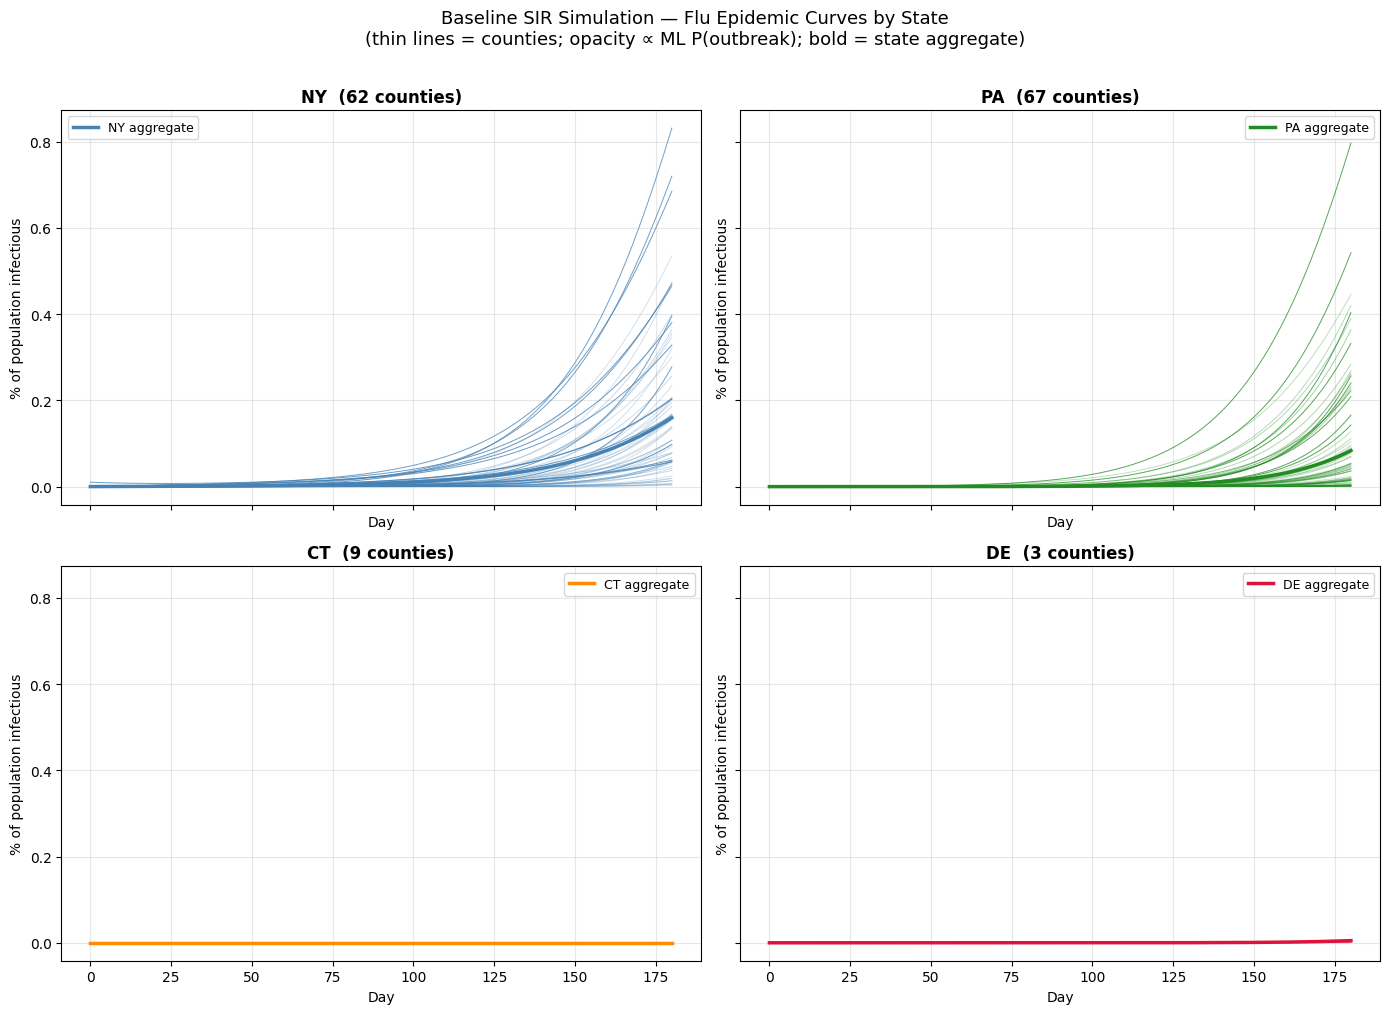

Saved: sir_epidemic_curves.png


In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)

for ax, state in zip(axes.flat, ['NY', 'PA', 'CT', 'DE']):
    color = STATE_COLORS[state]
    state_fips = [f for f in baseline['fips_order'] if fips_to_state[f] == state]
    idx = [baseline['fips_order'].index(f) for f in state_fips]

    I_pct = baseline['I'][idx] / baseline['N'][idx, None] * 100
    t     = baseline['t']

    for i, fips in enumerate(state_fips):
        a = 0.2 + 0.6 * fips_to_p[fips]
        ax.plot(t, I_pct[i], color=color, alpha=a, linewidth=0.7)

    # State aggregate
    I_agg = baseline['I'][idx].sum(axis=0)
    N_agg = baseline['N'][idx].sum()
    ax.plot(t, I_agg / N_agg * 100, color=color, linewidth=2.5,
            label=f'{state} aggregate', zorder=5)

    ax.set_title(f'{state}  ({len(state_fips)} counties)', fontsize=12, fontweight='bold')
    ax.set_ylabel('% of population infectious')
    ax.set_xlabel('Day')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle(
    'Baseline SIR Simulation — Flu Epidemic Curves by State\n'
    '(thin lines = counties; opacity ∝ ML P(outbreak); bold = state aggregate)',
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.savefig('../models/sir_epidemic_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: sir_epidemic_curves.png")

## 9  Visualisation — county peak infection rates

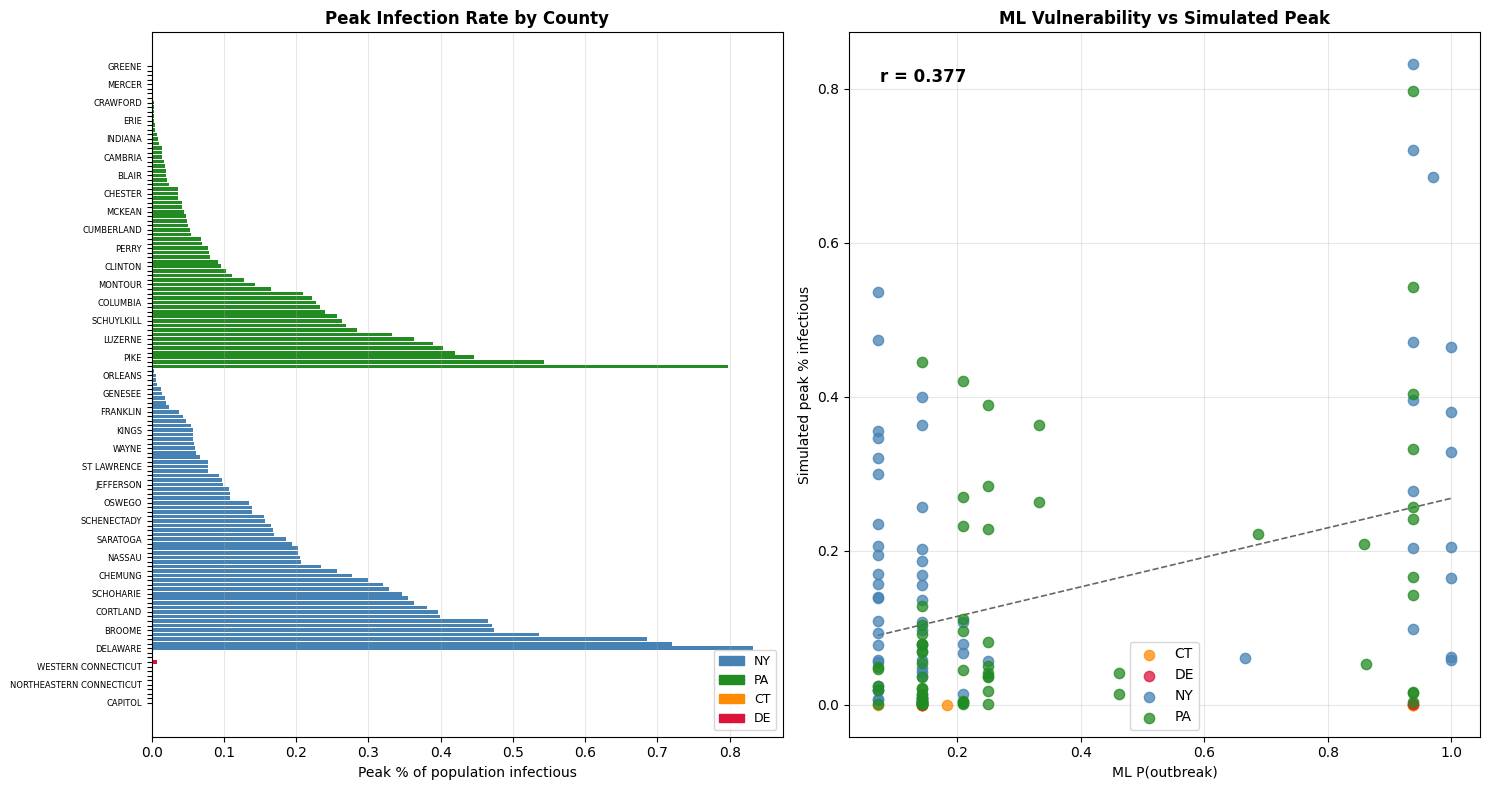

Saved: sir_county_peaks.png


In [22]:
peak_sorted = peak_df.sort_values(['state', 'peak_infected_pct'], ascending=[True, False])

fig, axes = plt.subplots(1, 2, figsize=(15, 8))

# --- left: horizontal bar chart ---
ax = axes[0]
bar_colors = [STATE_COLORS[s] for s in peak_sorted['state']]
ax.barh(range(len(peak_sorted)), peak_sorted['peak_infected_pct'],
        color=bar_colors, edgecolor='none', height=0.8)
ax.set_yticks(range(len(peak_sorted)))
labels = [
    row.county.replace(' County', '').replace(' Planning Region', '')
    if i % 4 == 0 else ''
    for i, row in enumerate(peak_sorted.itertuples())
]
ax.set_yticklabels(labels, fontsize=6)
ax.set_xlabel('Peak % of population infectious')
ax.set_title('Peak Infection Rate by County', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
legend_patches = [mpatches.Patch(color=v, label=k) for k, v in STATE_COLORS.items()]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)

# --- right: ML P(outbreak) vs simulated peak ---
ax2 = axes[1]
for state, grp in peak_df.groupby('state'):
    ax2.scatter(grp['p_outbreak'], grp['peak_infected_pct'],
                label=state, color=STATE_COLORS[state], alpha=0.75, s=55, zorder=3)

r = np.corrcoef(peak_df['p_outbreak'], peak_df['peak_infected_pct'])[0, 1]
m, b = np.polyfit(peak_df['p_outbreak'], peak_df['peak_infected_pct'], 1)
x_line = np.linspace(peak_df['p_outbreak'].min(), peak_df['p_outbreak'].max(), 50)
ax2.plot(x_line, m * x_line + b, 'k--', linewidth=1.2, alpha=0.6)
ax2.text(0.05, 0.95, f'r = {r:.3f}', transform=ax2.transAxes,
         fontsize=12, va='top', fontweight='bold')
ax2.set_xlabel('ML P(outbreak)')
ax2.set_ylabel('Simulated peak % infectious')
ax2.set_title('ML Vulnerability vs Simulated Peak', fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../models/sir_county_peaks.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: sir_county_peaks.png")

## 10  Policy intervention scenarios

In [23]:
SCENARIOS = {
    'Baseline':            {'vax_boost': 0.00, 'mobility_factor': 1.00},
    '+10% vaccination':    {'vax_boost': 0.10, 'mobility_factor': 1.00},
    '+20% vaccination':    {'vax_boost': 0.20, 'mobility_factor': 1.00},
    'Mobility −25%':       {'vax_boost': 0.00, 'mobility_factor': 0.75},
    'Mobility −50%':       {'vax_boost': 0.00, 'mobility_factor': 0.50},
    '+10% vax + mob −25%': {'vax_boost': 0.10, 'mobility_factor': 0.75},
}

print("Running policy scenarios …")
scenario_results = {}
for name, params in SCENARIOS.items():
    res = run_simulation(flu, adj_dict, **params)
    I_agg = res['I'].sum(axis=0)
    N_tot = res['N'].sum()
    scenario_results[name] = {
        'results':            res,
        'total_peak_pct':     float(I_agg.max() / N_tot * 100),
        'total_infected_pct': float(res['R'][:, -1].sum() / N_tot * 100),
        'peak_day':           float(res['t'][np.argmax(I_agg)]),
        'params':             params,
    }
    print(
        f"  {name:<28} peak={scenario_results[name]['total_peak_pct']:5.2f}%  "
        f"total_infected={scenario_results[name]['total_infected_pct']:5.1f}%  "
        f"peak_day={scenario_results[name]['peak_day']:.0f}"
    )
print("Done.")

Running policy scenarios …
  Baseline                     peak= 0.11%  total_infected= 59.3%  peak_day=180
  +10% vaccination             peak= 0.00%  total_infected= 68.9%  peak_day=26
  +20% vaccination             peak= 0.00%  total_infected= 78.9%  peak_day=0
  Mobility −25%                peak= 0.01%  total_infected= 58.9%  peak_day=180
  Mobility −50%                peak= 0.00%  total_infected= 58.9%  peak_day=180
  +10% vax + mob −25%          peak= 0.00%  total_infected= 68.9%  peak_day=12
Done.


## 11  Visualisation — policy comparison

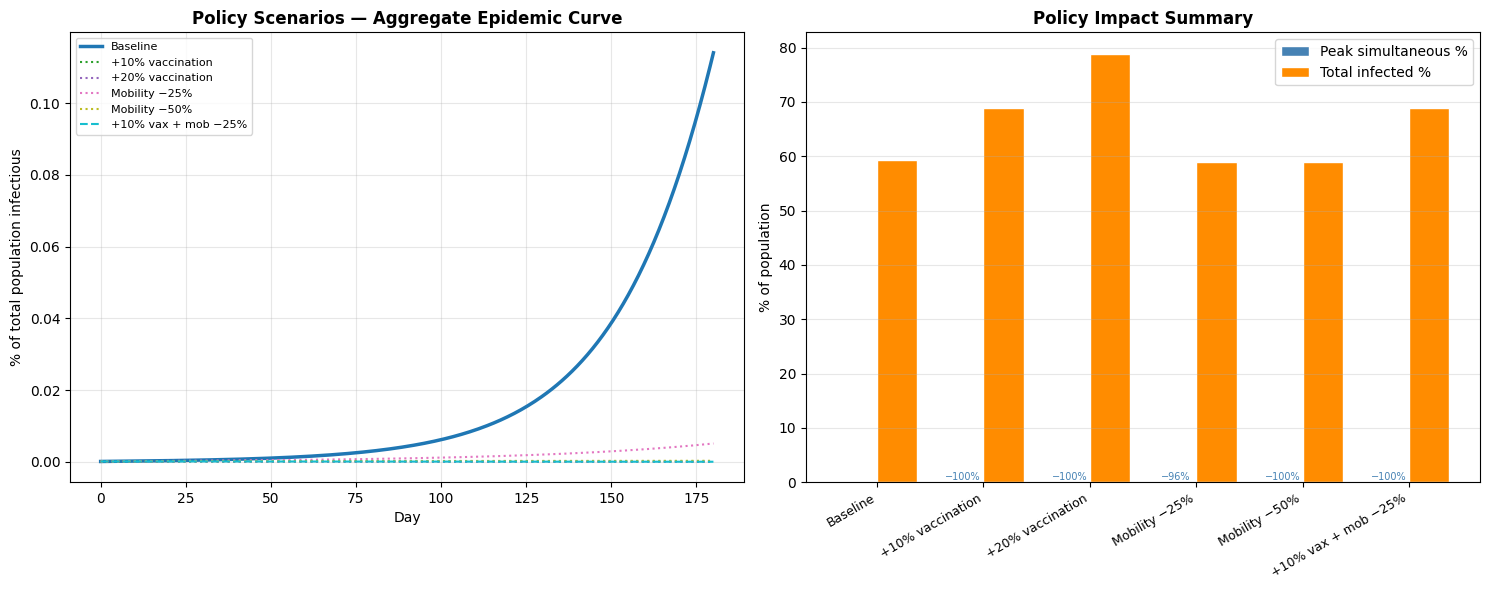

Saved: sir_policy_comparison.png


In [24]:
palette = plt.cm.tab10(np.linspace(0, 1, len(SCENARIOS)))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- left: epidemic curves ---
ax = axes[0]
for (name, sr), color in zip(scenario_results.items(), palette):
    r   = sr['results']
    I_a = r['I'].sum(axis=0) / r['N'].sum() * 100
    lw  = 2.5 if name == 'Baseline' else 1.5
    ls  = '-' if name == 'Baseline' else ('--' if 'vax' in name else ':')
    ax.plot(r['t'], I_a, color=color, linewidth=lw, linestyle=ls, label=name)

ax.set_xlabel('Day')
ax.set_ylabel('% of total population infectious')
ax.set_title('Policy Scenarios — Aggregate Epidemic Curve', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# --- right: bar summary ---
ax2  = axes[1]
names  = list(scenario_results.keys())
x      = np.arange(len(names))
w      = 0.38
peaks  = [scenario_results[n]['total_peak_pct']    for n in names]
totals = [scenario_results[n]['total_infected_pct'] for n in names]

ax2.bar(x - w/2, peaks,  w, label='Peak simultaneous %', color='steelblue',  edgecolor='white')
ax2.bar(x + w/2, totals, w, label='Total infected %',     color='darkorange', edgecolor='white')
ax2.set_xticks(x)
ax2.set_xticklabels(names, rotation=30, ha='right', fontsize=9)
ax2.set_ylabel('% of population')
ax2.set_title('Policy Impact Summary', fontweight='bold')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Annotate % reduction vs baseline on peak bars
base_peak = scenario_results['Baseline']['total_peak_pct']
for i, (name, val) in enumerate(zip(names, peaks)):
    if name != 'Baseline':
        pct_red = (base_peak - val) / base_peak * 100
        ax2.text(i - w/2, val + 0.02, f'−{pct_red:.0f}%',
                 ha='center', va='bottom', fontsize=7, color='steelblue')

plt.tight_layout()
plt.savefig('../models/sir_policy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: sir_policy_comparison.png")

## 12  Export results for Flask frontend

Writes `models/sir_results.json` with:
- `metadata` — model provenance, epidemiological constants
- `counties` — per-county params + baseline I(t) time series (sampled every 2 days)
- `adjacency` — list of `[fips_a, fips_b]` pairs for the region
- `scenarios` — summary stats for all 6 policy scenarios

In [25]:
# Subsample time series: every 4th point (0.5-day res → 2-day res)
t_sub = baseline['t'][::4].tolist()

county_records = []
for i, fips in enumerate(baseline['fips_order']):
    row = flu[flu['fips_str'] == fips].iloc[0]
    county_records.append({
        'fips':              fips,
        'county':            row['county'],
        'state':             row['state'],
        'pop_total':         int(row['N']),
        'pct_vaccinated':    round(float(row['V0'] * 100), 1),
        'p_outbreak':        round(float(row['p_outbreak']), 4),
        'beta':              round(float(row['beta']), 5),
        'gamma':             round(float(GAMMA), 5),
        'peak_infected_pct': round(float(baseline['peak_infected_pct'][i]), 3),
        'peak_day':          round(float(baseline['peak_day'][i]), 1),
        'I_series':          [round(v, 2) for v in baseline['I'][i, ::4].tolist()],
        't_series':          [round(v, 1) for v in t_sub],
    })

out = {
    'metadata': {
        'production_model':  'RandomForest',
        'pr_auc':            0.5064,
        'gamma':             GAMMA,
        'R0_base':           R0_BASE,
        'beta_base':         round(BETA_BASE, 5),
        'ML_scale':          ML_SCALE,
        'alpha':             ALPHA,
        'T_days':            T_SIM,
        'seed_n':            SEED_N,
        'n_counties':        len(county_records),
    },
    'counties':  county_records,
    'adjacency': adj_local[['fips_a', 'fips_b']].values.tolist(),
    'scenarios': {
        name: {
            'params':             sr['params'],
            'total_peak_pct':     round(sr['total_peak_pct'],     3),
            'total_infected_pct': round(sr['total_infected_pct'], 1),
            'peak_day':           round(sr['peak_day'],           1),
        }
        for name, sr in scenario_results.items()
    },
}

with open('../models/sir_results.json', 'w') as fh:
    json.dump(out, fh, indent=2)

print(f"Exported sir_results.json")
print(f"  {len(county_records)} counties  |  {len(adj_local)} adjacency pairs  |  {len(SCENARIOS)} scenarios")
print("\nNotebook 09 complete.")

Exported sir_results.json
  141 counties  |  678 adjacency pairs  |  6 scenarios

Notebook 09 complete.


## 13. Rank Validation Against Real Data

Absolute infection numbers from the SIR cannot be validated directly against real case counts — the model is not calibrated to reproduce true incidence. The relevant question is **whether the SIR correctly ranks counties by relative burden**, which determines whether it is useful for resource allocation.

Four metrics are computed, all rank-based:

| Metric | What it measures |
|---|---|
| **Spearman ρ** | Monotonic rank correlation between SIR peak and real outcome/100k |
| **Kendall τ** | Fraction of county pairs ranked correctly (concordance) |
| **AUC** | SIR's ability to separate outbreak vs non-outbreak counties |
| **Top-K precision** | Of the K counties SIR ranks highest, how many are actually top-K? |

All metrics are computed within-state as well as overall — cross-state comparisons are confounded by surveillance differences (PA and NY use different reporting systems). Within-state metrics are the primary result.

For comparison, all metrics are also computed using raw `p_outbreak` from the ML model, so we can see whether running the SIR adds value over just using the ML prediction directly.

**Expected results (Variant C — 3-point seed + uniform V0)**:
- Overall Spearman ρ = +0.448, AUC = 0.680, Top-10 precision = 0.45
- NY ρ = +0.351 (p=0.005), PA ρ = +0.503 (p<0.001)

=== SIR Rank Validation vs Real Flu Burden ===

                                SIR peak %    p_outbreak (ML)
Overall Spearman ρ              +0.448         +0.312
Overall Kendall τ               +0.311         +0.238

Within-state Spearman ρ (SIR vs real outcome/100k):
  CT (n=  9):  SIR ρ = +nan   ML ρ = +0.896   (p=nan)
  DE: skipped (n=3 < 4)
  NY (n= 62):  SIR ρ = +0.351*   ML ρ = +0.572   (p=0.005)
  PA (n= 67):  SIR ρ = +0.503*   ML ρ = +0.692   (p=0.000)

AUC (score vs outbreak label, 0.5=random, 1.0=perfect):
                SIR    ML
  Overall       0.680  1.000
  CT            0.500  1.000
  DE            0.500  1.000
  NY            0.760  1.000
  PA            0.725  0.999

Top-K precision (within-state mean across eligible states):
  K      SIR    ML     Random baseline
  K=5    0.40   0.53   0.11
  K=10   0.45   0.70   0.16
  K=15   0.47   0.93   0.23
  K=20   0.55   0.82   0.31


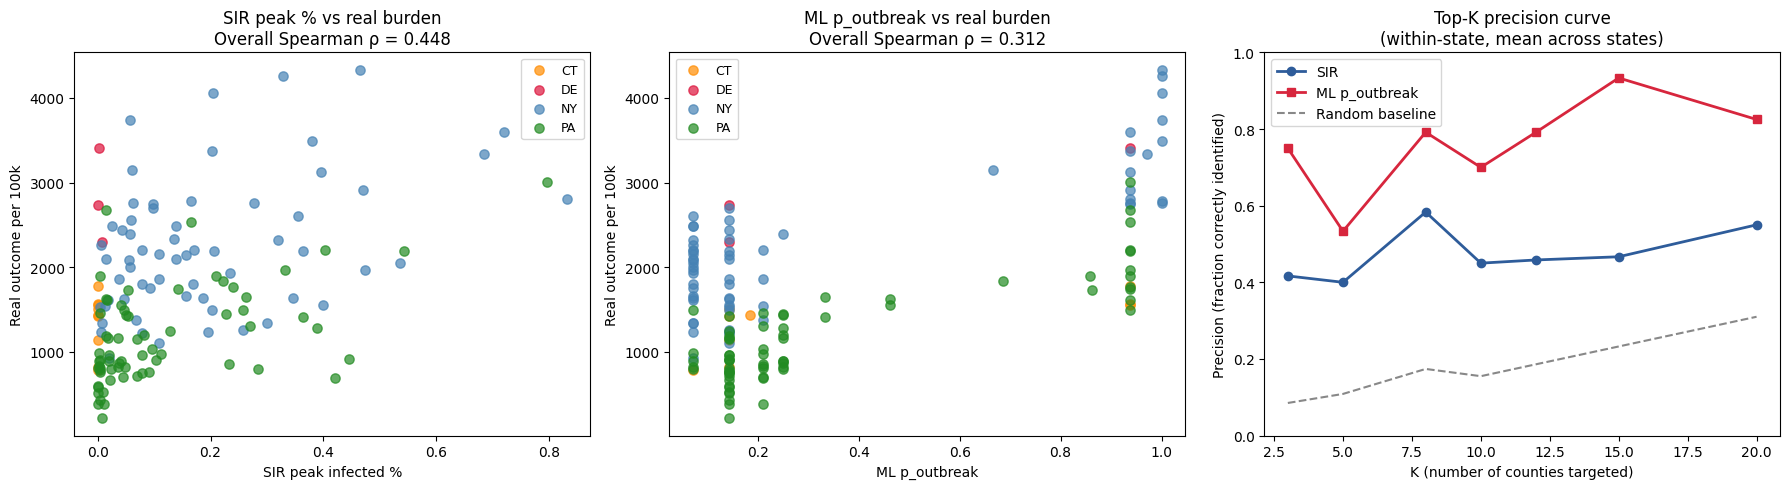

In [26]:
from scipy.stats import spearmanr, kendalltau
from sklearn.metrics import roc_auc_score

# Merge SIR outputs with real ground-truth
val = peak_df.merge(
    flu[['fips_str', 'outcome_per_100k', 'time_to_peak', 'outbreak']],
    left_on='fips', right_on='fips_str', how='left',
)

# ── 1. Overall rank correlations ─────────────────────────────────────────
rho_sir, p_rho_sir   = spearmanr(val['peak_infected_pct'], val['outcome_per_100k'])
tau_sir, p_tau_sir   = kendalltau(val['peak_infected_pct'], val['outcome_per_100k'])
rho_ml,  p_rho_ml    = spearmanr(val['p_outbreak'],         val['outcome_per_100k'])
tau_ml,  p_tau_ml    = kendalltau(val['p_outbreak'],         val['outcome_per_100k'])

print('=== SIR Rank Validation vs Real Flu Burden ===\n')
print(f'{"":30s}  SIR peak %    p_outbreak (ML)')
print(f'{"Overall Spearman ρ":<30s}  {rho_sir:+.3f}         {rho_ml:+.3f}')
print(f'{"Overall Kendall τ":<30s}  {tau_sir:+.3f}         {tau_ml:+.3f}')

# ── 2. Within-state Spearman ─────────────────────────────────────────────
print(f'\nWithin-state Spearman ρ (SIR vs real outcome/100k):')
for state, grp in val.groupby('state'):
    if len(grp) < 4:
        print(f'  {state}: skipped (n={len(grp)} < 4)')
        continue
    rho_s, p_s   = spearmanr(grp['peak_infected_pct'], grp['outcome_per_100k'])
    rho_ml_s, _  = spearmanr(grp['p_outbreak'],         grp['outcome_per_100k'])
    sig = '*' if p_s < 0.05 else (' ~' if p_s < 0.1 else '')
    print(f'  {state} (n={len(grp):3d}):  SIR ρ = {rho_s:+.3f}{sig}   ML ρ = {rho_ml_s:+.3f}   (p={p_s:.3f})')

# ── 3. AUC: score vs outbreak binary label ───────────────────────────────
auc_sir_all = roc_auc_score(val['outbreak'], val['peak_infected_pct'])
auc_ml_all  = roc_auc_score(val['outbreak'], val['p_outbreak'])
print(f'\nAUC (score vs outbreak label, 0.5=random, 1.0=perfect):')
print(f'  {"":12s}  SIR    ML')
print(f'  {"Overall":<12s}  {auc_sir_all:.3f}  {auc_ml_all:.3f}')
for state, grp in val.groupby('state'):
    if grp['outbreak'].nunique() < 2:
        print(f'  {state:<12s}  skipped (single class)')
        continue
    auc_s   = roc_auc_score(grp['outbreak'], grp['peak_infected_pct'])
    auc_ml_s = roc_auc_score(grp['outbreak'], grp['p_outbreak'])
    print(f'  {state:<12s}  {auc_s:.3f}  {auc_ml_s:.3f}')

# ── 4. Top-K precision (within state, states with n ≥ K only) ───────────
print(f'\nTop-K precision (within-state mean across eligible states):')
print(f'  {"K":<5}  SIR    ML     Random baseline')
for K in [5, 10, 15, 20]:
    prec_sir, prec_ml = [], []
    for state, grp in val.groupby('state'):
        if len(grp) < K:
            continue
        top_sir  = set(grp.nlargest(K, 'peak_infected_pct')['fips'])
        top_ml   = set(grp.nlargest(K, 'p_outbreak')['fips'])
        top_real = set(grp.nlargest(K, 'outcome_per_100k')['fips'])
        prec_sir.append(len(top_sir & top_real) / K)
        prec_ml.append( len(top_ml  & top_real) / K)
    random_baseline = K / val.groupby('state').size().reindex(
        [s for s, g in val.groupby('state') if len(g) >= K]
    ).mean()
    if prec_sir:
        print(f'  K={K:<3}  {np.mean(prec_sir):.2f}   {np.mean(prec_ml):.2f}   {random_baseline:.2f}')

# ── 5. Plots ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scatter: SIR peak vs real outcome/100k
ax = axes[0]
for state, grp in val.groupby('state'):
    ax.scatter(grp['peak_infected_pct'], grp['outcome_per_100k'],
               label=state, color=STATE_COLORS[state], alpha=0.7, s=45)
ax.set_xlabel('SIR peak infected %')
ax.set_ylabel('Real outcome per 100k')
ax.set_title(f'SIR peak % vs real burden\nOverall Spearman ρ = {rho_sir:.3f}')
ax.legend(fontsize=9)

# Scatter: ML p_outbreak vs real outcome/100k
ax = axes[1]
for state, grp in val.groupby('state'):
    ax.scatter(grp['p_outbreak'], grp['outcome_per_100k'],
               label=state, color=STATE_COLORS[state], alpha=0.7, s=45)
ax.set_xlabel('ML p_outbreak')
ax.set_ylabel('Real outcome per 100k')
ax.set_title(f'ML p_outbreak vs real burden\nOverall Spearman ρ = {rho_ml:.3f}')
ax.legend(fontsize=9)

# Top-K precision curve
ax = axes[2]
K_vals = [3, 5, 8, 10, 12, 15, 20]
prec_sir_curve, prec_ml_curve, random_curve = [], [], []
for K in K_vals:
    ps, pm = [], []
    eligible_ns = []
    for state, grp in val.groupby('state'):
        if len(grp) < K:
            continue
        top_sir  = set(grp.nlargest(K, 'peak_infected_pct')['fips'])
        top_ml   = set(grp.nlargest(K, 'p_outbreak')['fips'])
        top_real = set(grp.nlargest(K, 'outcome_per_100k')['fips'])
        ps.append(len(top_sir & top_real) / K)
        pm.append(len(top_ml  & top_real) / K)
        eligible_ns.append(len(grp))
    prec_sir_curve.append(np.mean(ps) if ps else np.nan)
    prec_ml_curve.append(np.mean(pm) if pm else np.nan)
    random_curve.append(K / np.mean(eligible_ns) if eligible_ns else np.nan)

ax.plot(K_vals, prec_sir_curve, marker='o', color='#2E5C9A', linewidth=2, label='SIR')
ax.plot(K_vals, prec_ml_curve,  marker='s', color='#D7263D',  linewidth=2, label='ML p_outbreak')
ax.plot(K_vals, random_curve,   linestyle='--', color='#888888', linewidth=1.5, label='Random baseline')
ax.set_xlabel('K (number of counties targeted)')
ax.set_ylabel('Precision (fraction correctly identified)')
ax.set_title('Top-K precision curve\n(within-state, mean across states)')
ax.legend(); ax.set_ylim(0, 1)

plt.tight_layout(); plt.show()